In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv(Path("../") / "Results"/ "perf_benchmark.csv")
df

,subject,dataset,model,epoch_window,accuracy
0,1,Dreyer2023,Deep4Net,w_00_40,0.81875
1,1,Lee2019_MI,Deep4Net,w_00_30,0.64000
2,2,Lee2019_MI,Deep4Net,w_00_30,0.65000
3,3,Lee2019_MI,Deep4Net,w_00_30,0.85000
4,4,Lee2019_MI,Deep4Net,w_00_30,0.77000
...,...,...,...,...,...
273,84,Dreyer2023,Deep4Net,w_05_45,0.72500
274,85,Dreyer2023,Deep4Net,w_05_45,0.68750
275,86,Dreyer2023,Deep4Net,w_05_45,0.63750
276,87,Dreyer2023,Deep4Net,w_05_45,0.79375


     subject     dataset     model epoch_window  accuracy
0          1  Dreyer2023  Deep4Net      w_00_40   0.81875
109        2  Dreyer2023  Deep4Net      w_00_40   0.73125
110        3  Dreyer2023  Deep4Net      w_00_40   0.84375
111        4  Dreyer2023  Deep4Net      w_00_40   0.86875
112        5  Dreyer2023  Deep4Net      w_00_40   0.80625
..       ...         ...       ...          ...       ...
188       83  Dreyer2023  Deep4Net      w_00_40   0.59375
189       84  Dreyer2023  Deep4Net      w_00_40   0.75625
190       85  Dreyer2023  Deep4Net      w_00_40   0.67500
191       86  Dreyer2023  Deep4Net      w_00_40   0.80625
192       87  Dreyer2023  Deep4Net      w_00_40   0.75000

[85 rows x 5 columns]
     subject     dataset     model epoch_window  accuracy
193        1  Dreyer2023  Deep4Net      w_05_45   0.65000
194        2  Dreyer2023  Deep4Net      w_05_45   0.56875
195        3  Dreyer2023  Deep4Net      w_05_45   0.55000
196        4  Dreyer2023  Deep4Net      w_05_45  

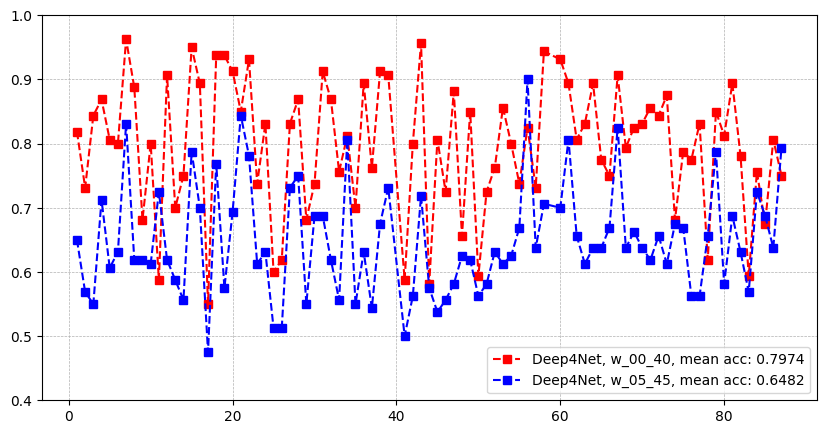

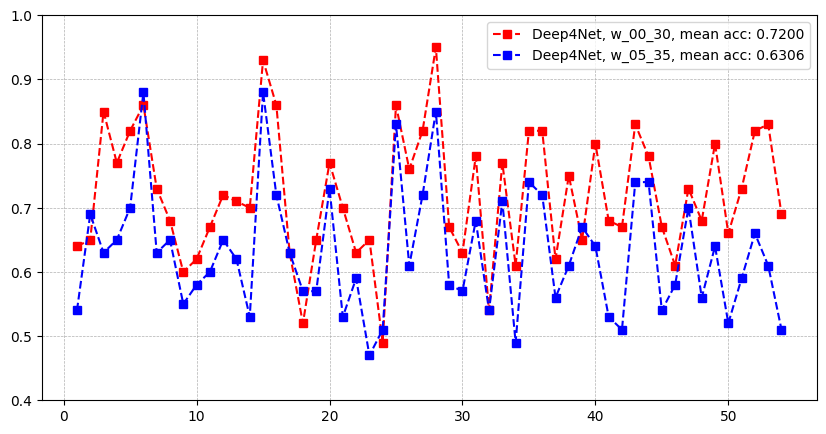

In [3]:

def plot_accuracy(df, dataset, model, windows = ["w_00_40", "w_05_45"], colors=["red", "blue"], ax=None):

    if ax is None:
        _, ax = plt.subplots()

    df = df[(df["dataset"] == dataset) & (df["model"] == model)]
    #print(df)
    for window, color in zip(windows, colors):
        df_window = df[df["epoch_window"] == window]
        print(df_window)
        df_window = df_window.sort_values("subject")
        mean_acc = df_window["accuracy"].mean()
        #print(f"{window}: {mean_acc:.4f}")
        #print(df_window)
        ax.plot(df_window["subject"], df_window["accuracy"], marker = "s", linestyle="--", label=f"{model}, {window}, mean acc: {mean_acc:.4f}", color=color)
    #df.plot(x="epoch_window", y="accuracy", kind="line")

    ax.set_ylim([0.4, 1.0])
    ax.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)


fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Dreyer2023", model="Deep4Net", ax=ax)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Lee2019_MI", model="Deep4Net", windows=["w_00_30", "w_05_35"], ax=ax)
